In [62]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
games = pd.read_csv('games.csv')

In [65]:
games[["id" , "black_rating" , "white_rating" , "turns" , "winner" , "opening_name"]].head(5)

,id,black_rating,white_rating,turns,winner,opening_name
0,TZJHLljE,1191,1500,13,white,Slav Defense: Exchange Variation
1,l1NXvwaE,1261,1322,16,black,Nimzowitsch Defense: Kennedy Variation
2,mIICvQHh,1500,1496,61,white,King's Pawn Game: Leonardis Variation
3,kWKvrqYL,1454,1439,61,white,Queen's Pawn Game: Zukertort Variation
4,9tXo1AUZ,1469,1523,95,white,Philidor Defense


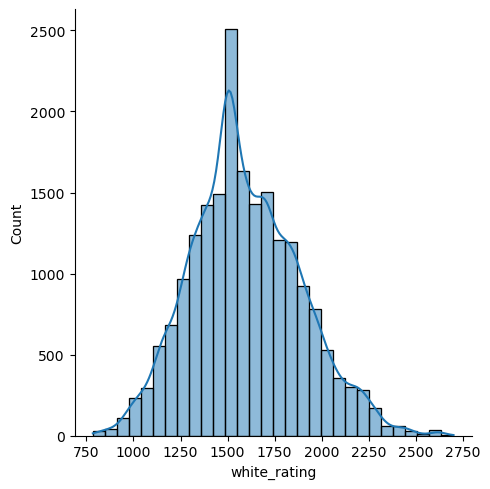

In [66]:
sns.displot(games['white_rating'] , kde = True , bins = 30)

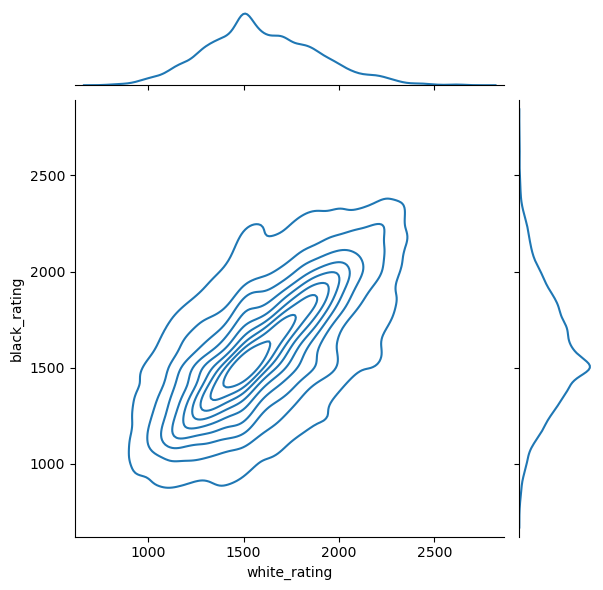

In [67]:
sns.jointplot(x = 'white_rating' , y = 'black_rating' , data = games , kind = 'kde')

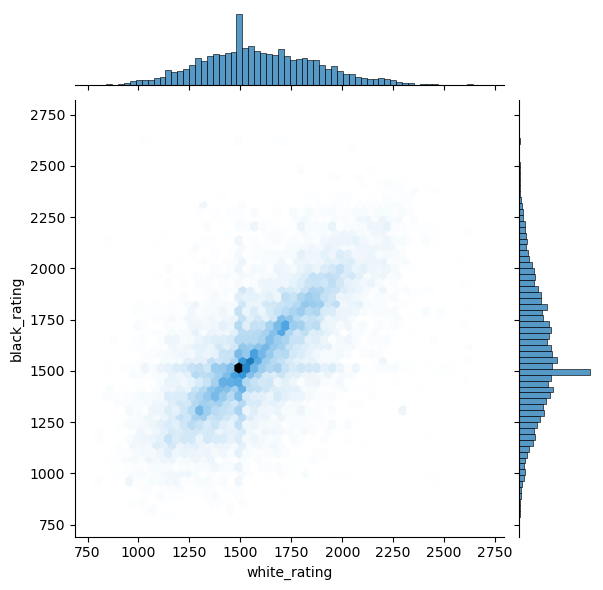

In [68]:
sns.jointplot(x = 'white_rating' , y = 'black_rating' , data = games , kind = 'hex')

<Axes: xlabel='black_rating', ylabel='Density'>

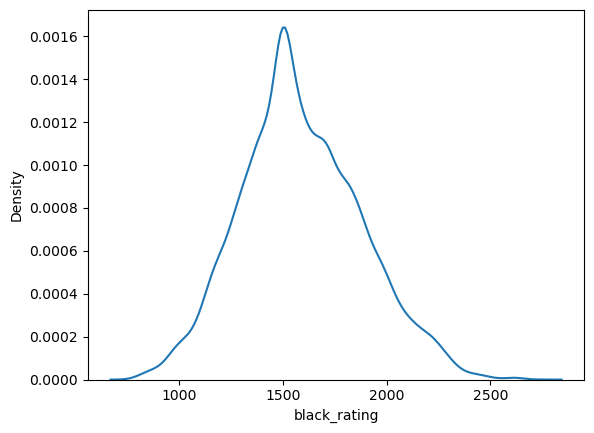

In [69]:
sns.kdeplot(games["black_rating"])

In [70]:
games[['winner' , 'opening_name' , 'white_rating' , 'black_rating']]

,winner,opening_name,white_rating,black_rating
0,white,Slav Defense: Exchange Variation,1500,1191
1,black,Nimzowitsch Defense: Kennedy Variation,1322,1261
2,white,King's Pawn Game: Leonardis Variation,1496,1500
3,white,Queen's Pawn Game: Zukertort Variation,1439,1454
4,white,Philidor Defense,1523,1469
...,...,...,...,...
20053,white,Dutch Defense,1691,1220
20054,black,Queen's Pawn,1233,1196
20055,white,Queen's Pawn Game: Mason Attack,1219,1286
20056,white,Pirc Defense,1360,1227


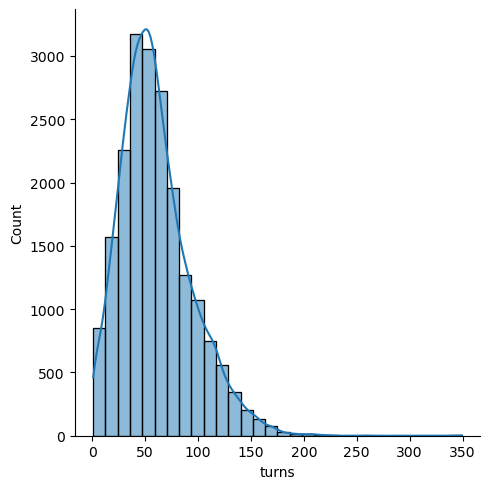

In [71]:
sns.displot(games["turns"] , kde = True , bins = 30)

In [72]:
games['white_win'] = (games['winner'] == 'white').astype(int)
games['black_win'] = (games['winner'] == 'black').astype(int)

white_win_rate = games['white_win'].mean()
black_win_rate = games['black_win'].mean()

print("White win rate:", white_win_rate)
print("Black win rate:", black_win_rate)

White win rate: 0.49860404826004584
Black win rate: 0.45403330342008175


Text(0, 0.5, 'Win Rate')

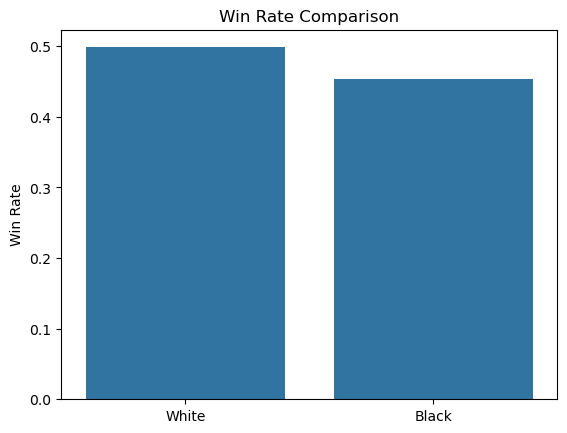

In [73]:
sns.barplot(x=['White', 'Black'], y=[white_win_rate, black_win_rate])
plt.title("Win Rate Comparison")
plt.ylabel("Win Rate")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_14184\1275213989.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate = games.groupby('rating_bin')['white_win'].mean()


Text(0.5, 1.0, 'Win Probability vs Rating Difference')

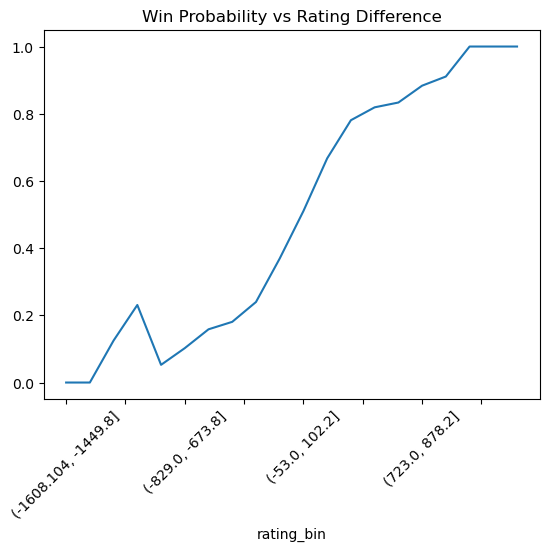

In [74]:
games['rating_diff'] = games['white_rating'] - games['black_rating']
games['rating_bin'] = pd.cut(games['rating_diff'], bins=20)
win_rate = games.groupby('rating_bin')['white_win'].mean()

win_rate.plot(kind='line')
plt.xticks(rotation=45)
plt.title("Win Probability vs Rating Difference")

In [75]:
top_openings = games['opening_name'].value_counts().head(10).index
filtered = games[games['opening_name'].isin(top_openings)]

opening_winrate = filtered.groupby('opening_name')['white_win'].mean().sort_values()

Text(0.5, 1.0, 'Win Rate by Opening (Top 10)')

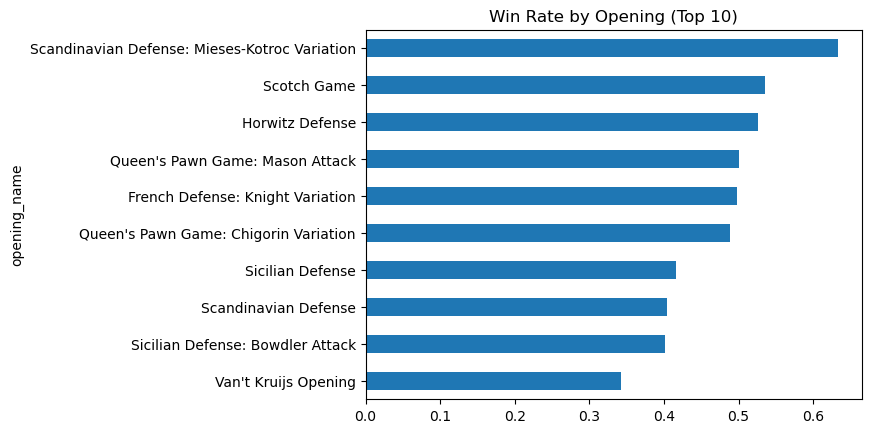

In [76]:
opening_winrate.plot(kind='barh')
plt.title("Win Rate by Opening (Top 10)")

Text(0.5, 1.0, 'Game Length by Winner')

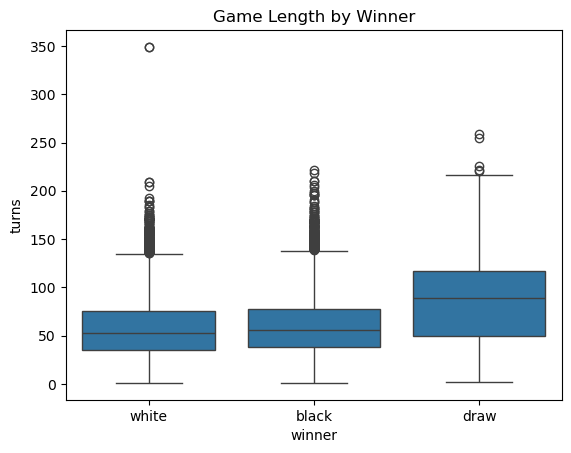

In [77]:
sns.boxplot(x='winner', y='turns', data=games)
plt.title("Game Length by Winner")

Text(0.5, 1.0, 'Distribution of White Player Ratings')

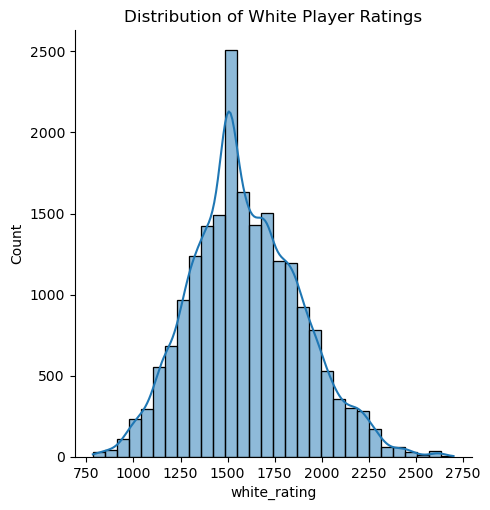

In [78]:
sns.displot(games['white_rating'], kde=True, bins=30)
plt.title("Distribution of White Player Ratings")

In [79]:
opening_stats = games.groupby('opening_name')['white_win'].agg(['count','mean'])
top_openings = opening_stats.sort_values('count', ascending=False).head(10)

Text(0, 0.5, 'Opening Name')

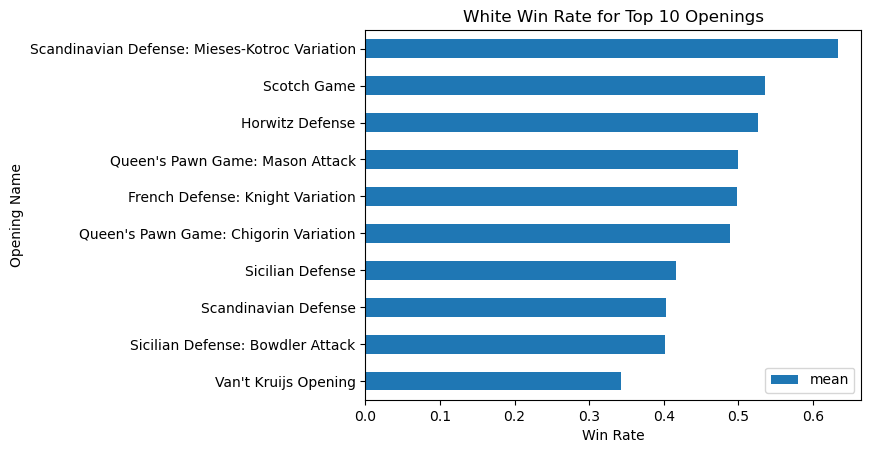

In [80]:
top_openings.sort_values('mean').plot(
    kind='barh',
    y='mean'
)

plt.title("White Win Rate for Top 10 Openings")
plt.xlabel("Win Rate")
plt.ylabel("Opening Name")